🚀 BHARATH BUILDS — 21 DAYS TO ML ENGINEER

DAY 3 — LINEAR REGRESSION

This day should move from “understanding the ML lifecycle” into your first actual supervised learning algorithm. The focus is on understanding what Linear Regression does, implementing it, and interpreting the result—not repeating

Day 1–2 EDA.

Objectives

By the end of Day 3, you should be able to:

Understand what a regression problem is.
Explain simple vs multiple linear regression.

Understand the best-fit line and residuals.

Understand why MSE is used as a loss function.

Train a Linear Regression model using scikit-learn.

Generate predictions and evaluate them using MAE, MSE, RMSE and R².

Inspect residuals and interpret model performance.

Document and commit your first regression model to GitHub.

Today's practical result

Dataset → Features → Linear Regression → Predictions → Metrics → Residual Analysis

STEP1 : IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

STEP2: LOADING DATA SET

In [2]:
from sklearn.datasets import fetch_california_housing

data = fetch_california_housing(as_frame=True)

X = data.data
y = data.target

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [3]:
X.tail()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32
20639,2.3886,16.0,5.254717,1.162264,1387.0,2.616981,39.37,-121.24


In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [5]:
X.shape

(20640, 8)

In [6]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [7]:
X.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


step4: model training and testing

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(16512, 8)
(4128, 8)
(16512,)
(4128,)


step5: creating the linear regression model


In [10]:
model=LinearRegression()

step6: model training

In [11]:
model.fit(X_train,y_train)

LinearRegression()

step 6: intercept , coefficent calculation


In [12]:
print("Intercept:", model.intercept_)

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients

Intercept: -37.02327770606409


,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


In [14]:
y_pred=model.predict(X_test)
print(y_pred[:10])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725 2.01175367
 2.64550005 2.16875532 2.74074644 3.91561473]


In [15]:
y_actual=y_test.values[:10]
print(y_actual)


[0.477   0.458   5.00001 2.186   2.78    1.587   1.982   1.575   3.4
 4.466  ]


In [19]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

comparison



,Actual,Predicted
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [20]:
# usinf MAE
mae=mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mae)

Mean Absolute Error: 0.5332001304956553


In [21]:
# calculate mse
mse=mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mse)

Mean Squared Error: 0.5558915986952444


In [22]:
# calculate rmse
rmse=np.sqrt(mse)
print("Root Mean Squared Error:",rmse)

Root Mean Squared Error: 0.7455813830127764


In [23]:
# calculating r2
r2=r2_score(y_test,y_pred)
print("R-squared:",r2)

R-squared: 0.5757877060324508


In [28]:
# ting dataframe of mae, rmse, r2, mse
metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Value": [mae, mse, rmse, r2]
})

metrics

,Metric,Value
0,MAE,0.533200
1,MSE,0.555892
2,RMSE,0.745581
3,R2,0.575788


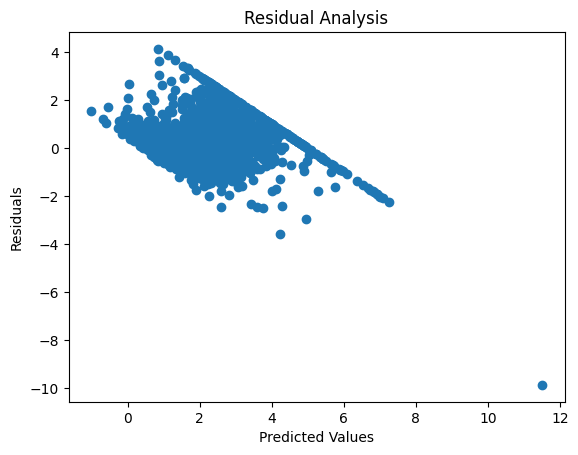

[-0.24212284 -1.30601657  2.29035117 ...  0.53123983 -0.46451119
 -0.49440251]


In [24]:
# residual value analysis
residual=y_test.values-y_pred
plt.scatter(y_pred,residual)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Analysis")
plt.show()

print(residual)


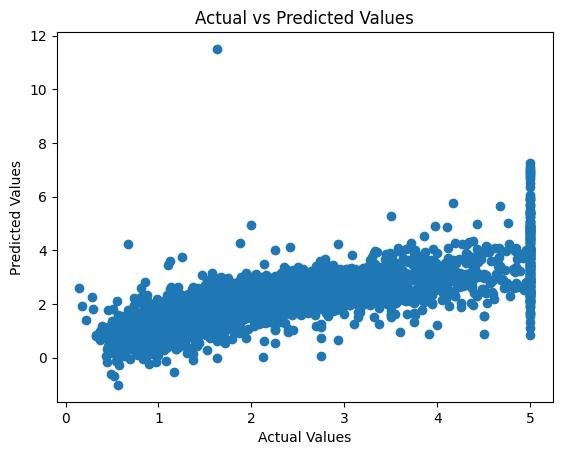

In [29]:
# r regrewssion graph

plt.scatter(y_test,y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")
plt.show()

In [30]:
# # interpretaion
# X-axis: Actual values
# Y-axis: Predicted values
# Ideally, the points should lie close to a 45° diagonal line (Actual = Predicted).
# Here, there is a clear positive relationship: as the actual value increases, the predictions generally increase.
# However, the points are widely scattered, especially for higher actual values.
# The model tends to underpredict higher target values. For example, when actual values are around 4–5, many predictions remain around 2–4.
# There are also some significant outliers where the prediction is far from the actual value.
# The vertical concentration around actual ≈ 5 indicates many target values are capped at the dataset's upper limit, which is characteristic of the California Housing dataset.
